<a href="https://colab.research.google.com/github/Spicyredd/Learn_PyTorch/blob/master/04_pytorch_custom_datasets_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. PyTorch Custom Datasets Video Notebook

We've used some datasets with PyTorch before.

But how do you get your own data into PyTorch?

One of the ways to do so is via:custom datasets.

## Domain Libraries

Depending on what you're working on, vision, test, audio, recommendation, you'll want to look into each of the PyTorch's existing data loading functions and customizable data loading functions

**Resources: **

* Book version of the course materials for 04: https://www.learnpytorch.io/04_pytorch_custom_datasets/

* Ground truth version of notebook 04: https://github.com/mrdbourke/pytorch-deep-learning/blob/main/04_pytorch_custom_datasets.ipynb


# 0. Import PyTorch and setting up device-agnostic code

In [ ]:
import torch
from torch import nn

# Note: PyTorch 1.10.0+ is required for this course
torch.__version__

'2.6.0+cu124'

In [ ]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## 1. Get data

Our dataset is a subset of the Food101 dataset.

Food101 starts 101 different classes of food and 1000 images per class (750 training, 250 testing).

Our dataset starts with 3 classes of food and only 10$ of the images (~75 training, 25 testing)

Why do this?

When starting out ML projects, its important to try things on a small scale and then increase the scale when necessary. The whole point is to speed up how fast you can experiment.

In [ ]:
import requests
import zipfile
from pathlib import Path
import zipfile

# Setup path to a data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...

if image_path.is_dir():
  print(f"{image_path} directory already exists... skipping download")
else:
  print(f"{image_path} does not exist, creating one...")
  image_path.mkdir(parents=True, exist_ok=True)

# Download pizza, steak and sushi data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")

  print("Downloading pizza, steak, sushi data...")
  f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
  print("Unzipping pizza, steak and sushi data...")
  zip_ref.extractall(image_path)

data/pizza_steak_sushi directory already exists... skipping download
Unzipping pizza, steak and sushi data...


## 2. Becoming one with the data (datapreparation and data exploration)

In [ ]:
import os

def walk_through_dir(dir_path):
  """
  Walks through dir path returning its contents.
  """

  for dirpath, dirnames, filesnames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filesnames)} images in '{dirpath}'")

In [ ]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'


In [ ]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing Image

Let's write some code to :
1. Get all of the image paths
2. Pick a random image path using Python's random.choice()
3. Get the image class name `pathlib.Path.parent.stem`
4. Since we're working with images, we will use python's PIL
5. We'll then show the image and print metadata


data/pizza_steak_sushi/test/steak/2117351.jpg
steak
Random image path: data/pizza_steak_sushi/test/steak/2117351.jpg
Image class: steak
Image height: 512
Image width: 512


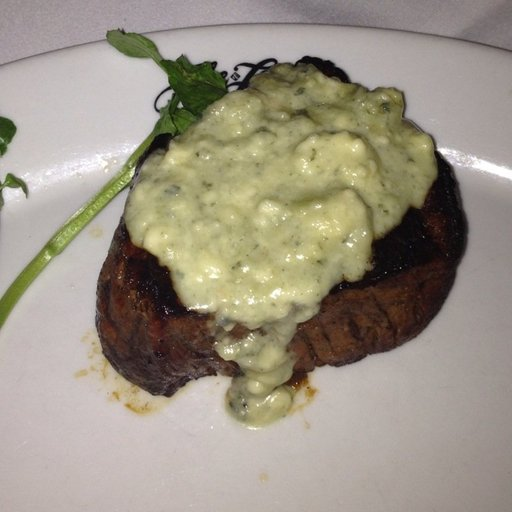

In [ ]:
import random
from PIL import Image

# Set seed
# random.seed(42)

# 1. Get all image paths ()
image_path_list = list(image_path.glob("*/*/*.jpg"))
random.shuffle(image_path_list)

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)
print(random_image_path)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem
print(image_class)

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

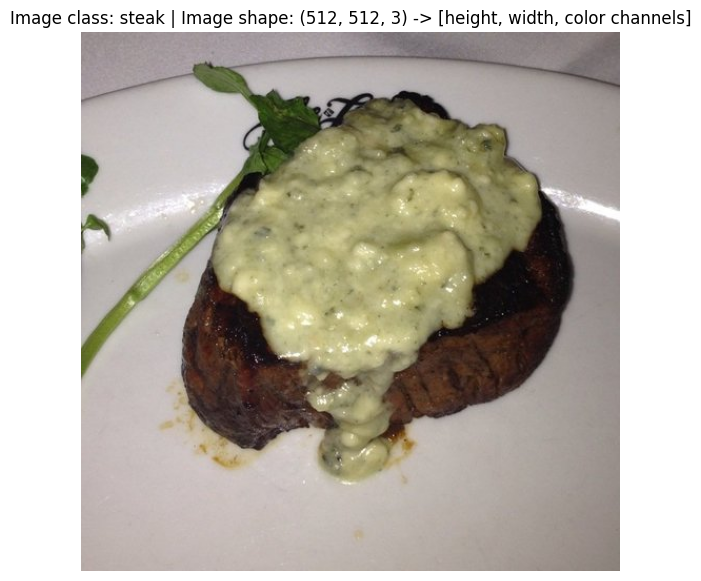

In [ ]:
# Try to visualize with matplotlib
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
image_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10,7))
plt.imshow(image_as_array)
plt.title(f"Image class: {image_class} | Image shape: {image_as_array.shape} -> [height, width, color channels]")
plt.axis(False)

## 3. Transforming data

Before we can use our image data with PyTorch:
1. Turn your target data in tensors (in our case, numerical representation of our images).
2. Turn it into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with torchvision.transforms

Transforms help you get your images ready to be used with a model/perform data augmentation -
https://pytorch.org/vision/stable/transforms.html


In [ ]:
# Write a transform for image
data_transform = transforms.Compose([
    # Resize out images to 64 x 64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    # Turn the image into a torch.Tensor
    transforms.ToTensor()
])

In [ ]:
data_transform(img).shape

torch.Size([3, 64, 64])

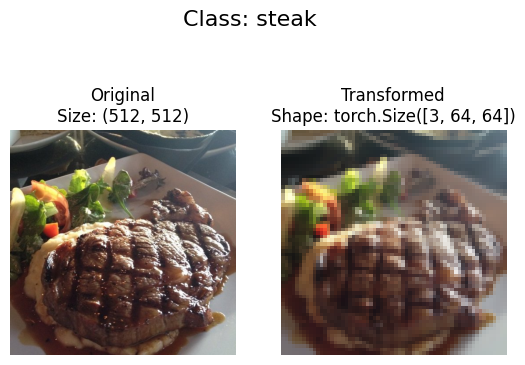

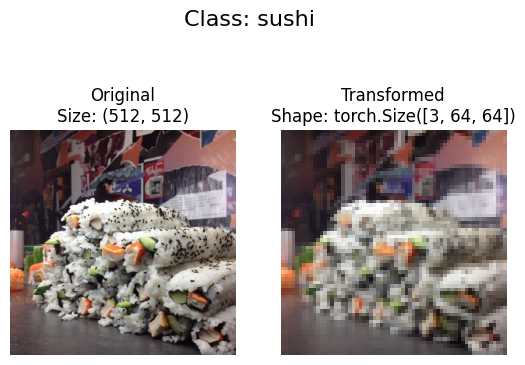

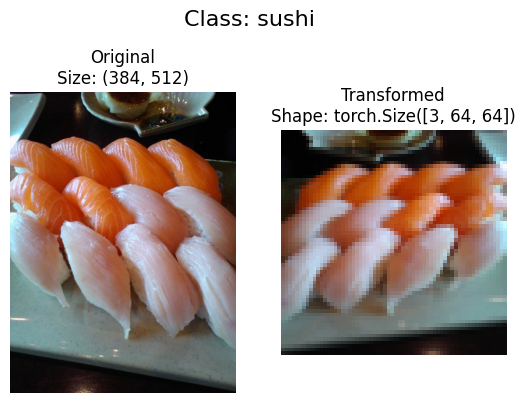

In [ ]:
def plot_transformed_images(image_paths, transform, n=3, seed=None):
  """
  Selects random images from a path of images and loads/transforms them then plots the original vs the transformed version.
  """
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1, ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize: {f.size}")
      ax[0].axis(False)

      # Transform and plot target image
      transformed_image = transform(f)
      ax[1].imshow(transformed_image.permute(1,2,0))
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis(False)

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=42
)

## 4. Option 1: Loading image data using `ImageFolder`

We can load image classification data using `torch.vision.datasets.ImageFolder -
https://pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder



In [ ]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform, # a transform for the data
                                  target_transform=None # transform for the target/label
                                  )

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform,
                                 target_transform=None)

train_data, test_data


(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [ ]:
# Get class names as lit
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [ ]:
# Get class names as dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
# Check the lengths of our dataset
len(train_data), len(test_data)

(225, 75)

In [ ]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [ ]:
# Index on the train_data Dataset to get a single image and label
img, label = train_data[0][0], train_data[0][1]
print(f"Image Tensor:\n {img}")
print(f"Image Shape: {img.shape}")
print(f"Image Datatype: {img.dtype}")
print(f"Image Label: {label}")
print(f"Label Datatype: {type(label)}")

Image Tensor:
 tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.0

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
New shape: torch.Size([64, 64, 3]) -> [height, width, color_channel]


Text(0.5, 1.0, 'pizza')

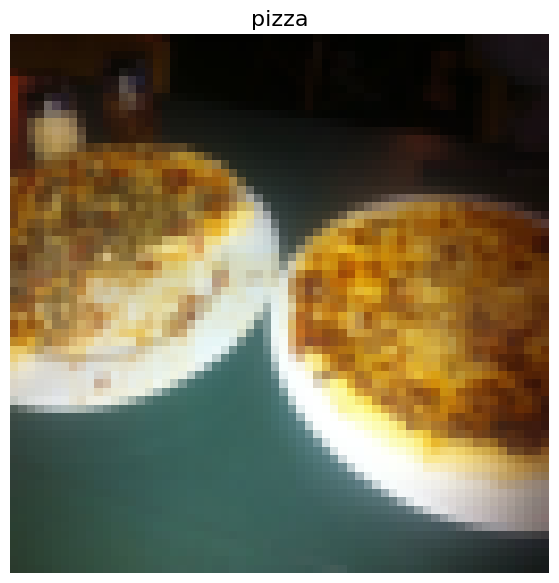

In [ ]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Pring out different shapes
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"New shape: {img_permute.shape} -> [height, width, color_channel]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img_permute)
plt.axis(False)
plt.title(class_names[label], fontsize=16)

## 4.1 Turn loaded images in `Dataloader`

A `DataLoader` is going to help us turn our `Dataset`'s into iterables and we can customize the `batch_size` so our model can see `batch_size` images at a time

In [ ]:
# Turn train and test datasets into DataLoader's
from torch.utils.data import DataLoader
BATCH_SIZE=32
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    num_workers=1,
    shuffle=True,
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    num_workers=1,
    shuffle=False,
)

In [ ]:
len(train_dataloader), len(test_dataloader)

(8, 3)

In [ ]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, you can change the batch size if you like
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


## 5 Option 2: Loading Image Data with a Custom `Dataset`

1. Want to be able to load images from file
2. Want to be able to get class names from the Dataset
3. Want to be able to get classes as dictionary from the Dataset

Pros:
* Can create a `Dataset` out of almost anything
* Not limited to PyTorch pre-built `Dataset` functions

Cons:
* Even though you could create `Dataset` out of almost anything, it doesn't mean it will work...
* Using a custom `Dataset` often results in us writing more code, which could be prone to errors or performance issues.

All custom datasets in PyTorch, often subclass - https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset


In [ ]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

### 5.1 Creating a helper function to get class names

We want a function to:
1. Get the class names using `os.scandir()` to traverse a target directory (ideally the directory is in standard image classification format).

2. Raise an error if the class names aren't found (if this happens, there might be wrong with the directory structure).

3. Turn the class names into a dict and a list and return them.

In [ ]:
# Setup path for target directory
target_directory = train_dir
print(f"Target dir: {target_directory}")

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target dir: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [ ]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
  """Finds the class folder names in a target directory."""

  # 1. Get the class names by scanning the target directory

  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  # 2. Raise an error if class names could not be found
  if not classes:
    raise FileNotFoundError(f"Could not find any classes in {directory}... please check file structure")

  # 3. Create a dictionary of index labels (computers prefer numbers rather than string as labels)
  class_to_idx = {class_name: i for i, class_name in enumerate(classes)}
  return classes, class_to_idx

In [ ]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [ ]:
# Make function to find classes in target directory
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folder names in a target directory.

    Assumes target directory is in standard image classification format.

    Args:
        directory (str): target directory to load classnames from.

    Returns:
        Tuple[List[str], Dict[str, int]]: (list_of_class_names, dict(class_name: idx...))

    Example:
        find_classes("food_images/train")
        >>> (["class_1", "class_2"], {"class_1": 0, ...})
    """
    # 1. Get the class names by scanning the target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    # 2. Raise an error if class names not found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}.")

    # 3. Create a dictionary of index labels (computers prefer numerical rather than string labels)
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

In [ ]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom `Dataset` to replicate `ImageFolder`

To create our own custom dataset, we want to:

1. Subclass `torch.utils.data.Dataset`
2. Init our subclass with a target directory (the directory we'd like to get data from) as well as a transform if we'd like to transform our data.
3. Create several attributes:
  * paths - paths of our images
  * transform - a list of the target classes
  * classes - a list of the target classes
  * class_to_idx - a dict of the target classes mapped to integer labels
4. Create a function to `load_images()`, this function will open an image
5. Overwrite the `__len__()` method to return the length of our dataset
6. Overwrite the `__getitem__()` method to return a given sample when passed an index

In [ ]:
# 0. Write a custom dataset class
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
  # 2. Initialize our custom dataset
  def __init__(self,
               targ_dir: str,
               transform=None):
    # 3. Create class attributes
    # Get all of the image paths
    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    # Setup transforms
    self.transform = transform
    # Create classes and class_to_idx attributes
    self.classes, self.class_to_idx = find_classes(targ_dir)

  # 4. Create a function to load images
  def load_image(self, index: int) -> Image.Image:
    """
    Opens an image via a path and returns it.
    """
    image_path = self.paths[index]
    return Image.open(image_path)

  # 5. Overwrite __len__()
  def __len__(self) -> int:
    """
    Returns the total number of samples.
    """
    return len(self.paths)

  # 6. Overwrite __getitem__() method to return a particular sample
  def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
    """
    Returns one sample of data and label (X, y).
    """
    img = self.load_image(index)
    class_name = self.paths[index].parent.name # expects path in format: data_folder/class_name/image.jpg
    class_idx = self.class_to_idx[class_name]

    # transform if necessary
    if self.transform:
      return self.transform(img), class_idx # return data, label (X, y)
    return img, class_idx # return data, label (X, y)

In [ ]:
train_data_custom = ImageFolderCustom(
    targ_dir=train_dir,
    transform=data_transform
)

test_data_custom = ImageFolderCustom(
    targ_dir=test_dir,
    transform=data_transform
)

In [ ]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
image, label = train_data_custom[0]
image, label

(tensor([[[0.4471, 0.4431, 0.4549,  ..., 0.4627, 0.5216, 0.4706],
          [0.4392, 0.4275, 0.4392,  ..., 0.4667, 0.5098, 0.5059],
          [0.4275, 0.4118, 0.4314,  ..., 0.4627, 0.5020, 0.5373],
          ...,
          [0.6235, 0.6039, 0.6039,  ..., 0.6392, 0.5922, 0.5451],
          [0.6471, 0.6235, 0.6157,  ..., 0.6078, 0.5765, 0.5333],
          [0.6784, 0.6510, 0.6392,  ..., 0.5569, 0.5451, 0.5294]],
 
         [[0.4275, 0.4314, 0.4353,  ..., 0.3608, 0.4275, 0.4980],
          [0.4235, 0.4235, 0.4275,  ..., 0.3608, 0.3961, 0.4745],
          [0.4118, 0.4196, 0.4157,  ..., 0.3608, 0.3882, 0.4431],
          ...,
          [0.5255, 0.5137, 0.5098,  ..., 0.5412, 0.4902, 0.4549],
          [0.5451, 0.5333, 0.5176,  ..., 0.5020, 0.4863, 0.4510],
          [0.5647, 0.5490, 0.5373,  ..., 0.4392, 0.4588, 0.4667]],
 
         [[0.2941, 0.2980, 0.3020,  ..., 0.2196, 0.2745, 0.3765],
          [0.2824, 0.2902, 0.2863,  ..., 0.2118, 0.2275, 0.3451],
          [0.2941, 0.2745, 0.2706,  ...,

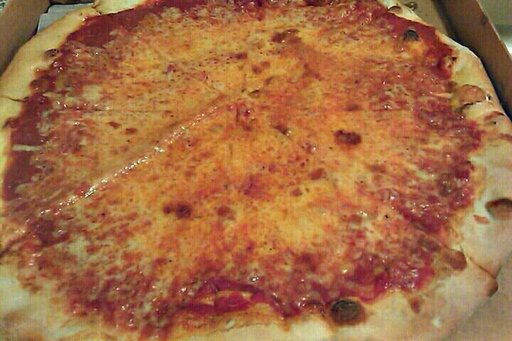

In [ ]:
train_data_custom.load_image(0)

### 5.3 Create a function to display random images

1. Take in a `Dataset` and a number of other parameters such as class names and how many images to visualize
2. To prevent the display getting out of hand, let's cap the number of images to see at 10.
3. Set the random seed for reproducibility
4. Get a list of random samples indexes from the target dataset.
5. Setup a matplotlib plot.
6. Loop through the random sample images and plot them with matplotlib.
7. Make sure the dimensions of our images line up with matplotlib (HWC)

In [ ]:
# Create a function to take in a dataset

def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
  # 2. Adjust display if n is too high
  if n > 10:
    n = 10
    display_shape = False
    print(f"For display purposes n shouldn't be larger than 10, setting to 10 and removing shape display.")

  # 3. Set the seed
  if seed:
    random.seed(seed)

  # 4. Get random sample indexes
  random_samples_idx = random.sample(range(len(dataset)), k=n)

  # 5. Setup plot
  plt.figure(figsize=(16, 8))

  # 6. Loop through random indexes and plot them with matplotlib
  for i, targ_sample in enumerate(random_samples_idx):
    targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

    # 7. Adjust tensor dimensions for plotting
    targ_image_adjust = targ_image.permute(1, 2, 0) # [color_channels, height, width] -> [height, width, color_channels]

    # Plot adjusted samples
    plt.subplot(1, n, i+1)
    plt.imshow(targ_image_adjust)
    plt.axis(False)
    if classes:
      title = f"Class: {classes[targ_label]}"
      if display_shape:
        title = title + f"\nshape: {targ_image_adjust.shape}"

    plt.title(title)

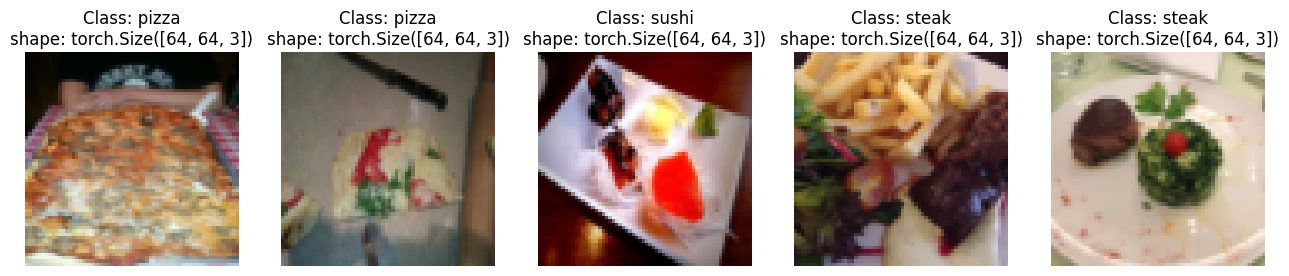

In [ ]:
# Dislay random images from the ImageFolder created Dataset
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=67)

For display purposes n shouldn't be larger than 10, setting to 10 and removing shape display.


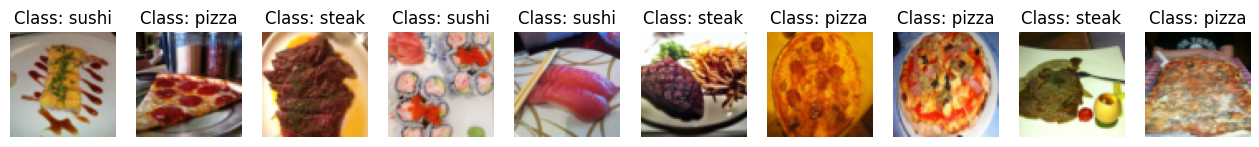

In [ ]:
# Display random images from the ImageFolderCustom Dataset
display_random_images(train_data_custom,
                      n=20,
                      classes=class_names,
                      seed=None)

### 5.4 Turn custom loaded images in `DataLoader`'s

In [ ]:
import os

BATCH_SIZE=32
NUM_WORKERS = os.cpu_count()

train_dataloader_custom = DataLoader(
    train_data_custom,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

test_dataloader_custom = DataLoader(
    test_data_custom,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7ec69c4cc650>,
 <torch.utils.data.dataloader.DataLoader at 0x7ec69c4ecd50>)

In [ ]:
# Get image and label from custom dataloader
img_custom , label_custom = next(iter(train_dataloader_custom))
img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

## 6. Other forms of transforms (data augumentation)

Data augumentation is the process of artificially adding diversity to your training data.

In the case of image data, this may mean applying various image transformations to the training images.

This practice hopefully results in a model that's more generalizable to unseen data.

Let's take a look at one particular type of data augumentation used to train PyTorch vision models to state of the art levels

Blog post: https://pytorch.org/blog/how-to-train-state-of-the-art-models-using-torchvision-latest-primitives#break-down-of-key-accuracy-improvements


In [ ]:
# Let's look at trivialaugment -
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor()
])

In [ ]:
# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/pizza/3475871.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/3092704.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2124579.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/930553.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/648055.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/398345.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/344397.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1925494.jpg')]

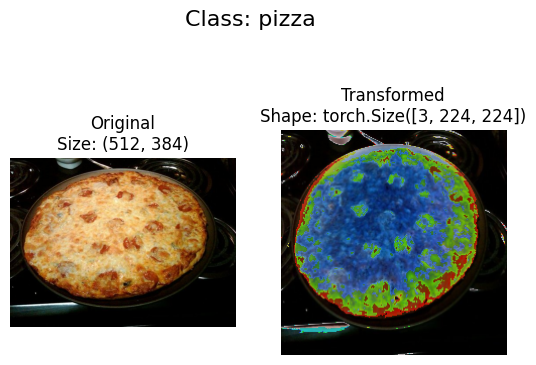

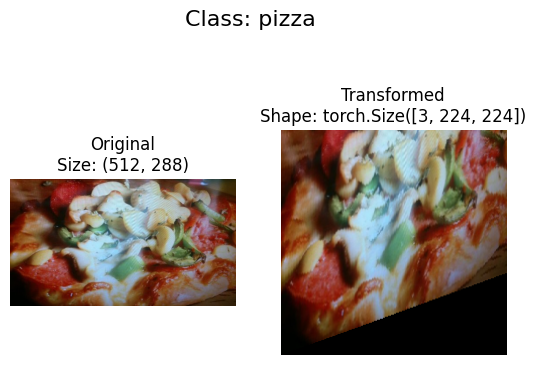

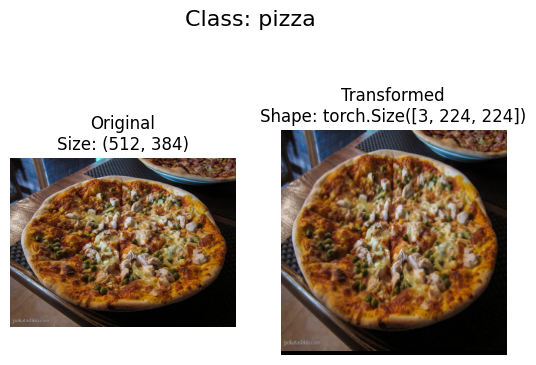

In [ ]:
# Plot random image
plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transform,
    n=3,
    seed=None
)

## 7. Model 0: TinyVGG without data augumentation

Let's replicate TinyVGG architecture from the CNN Explainer website: https://poloclub.github.io/cnn-explainer/


### 7.1 Creating transforms and loading data for Model 0

In [ ]:
# Create simple transforms
simple_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [ ]:
# 1. Load and transform data
from torchvision import datasets
train_data_simple = ImageFolderCustom(
    targ_dir=train_dir,
    transform=simple_transform,
)

test_data_simple = ImageFolderCustom(
    targ_dir=test_dir,
    transform=simple_transform
)

In [ ]:
# 2. Turn the datasets in DataLoaders
import os
from torch.utils.data import DataLoader

# Setup batch size and number of workers
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

# Create DataLoader's
train_dataloader_simple = DataLoader(
    train_data_simple,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

test_dataloader_simple = DataLoader(
    test_data_simple,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)

## 7.2 Create TinyVGG model class

In [ ]:
class TinyVGG(nn.Module):
  """
  Model architecture copying TinyVGG from CNN Explainer
  """
  def __init__(self, input_shape: int,
               hidden_units: int,
               output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2) # default stride value is same as kernel size fo maxpool2d
                  )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2) # default stride value is same as kernel size fo maxpool2d
                  )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(
            in_features=hidden_units * 13 * 13,
            out_features=3
        )
    )

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    x = self.conv_block_1(x)
    # print(x.shape)
    x = self.conv_block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    return x

In [ ]:
model_0 = TinyVGG(
    input_shape=3,
    hidden_units=8,
    output_shape=len(class_names)
).to(device)

### 7.3 Try a forward pass on a single image (to test the model)

In [ ]:
# Get a single image batch
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [ ]:
# try forward pass
model_0(image_batch)

tensor([[-0.0419, -0.0210, -0.0310],
        [-0.0408, -0.0284, -0.0294],
        [-0.0410, -0.0184, -0.0248],
        [-0.0438, -0.0222, -0.0301],
        [-0.0428, -0.0272, -0.0296],
        [-0.0390, -0.0287, -0.0316],
        [-0.0463, -0.0270, -0.0322],
        [-0.0383, -0.0154, -0.0292],
        [-0.0472, -0.0221, -0.0322],
        [-0.0411, -0.0276, -0.0297],
        [-0.0389, -0.0157, -0.0249],
        [-0.0407, -0.0252, -0.0304],
        [-0.0416, -0.0300, -0.0278],
        [-0.0414, -0.0124, -0.0296],
        [-0.0416, -0.0212, -0.0323],
        [-0.0459, -0.0258, -0.0279],
        [-0.0444, -0.0182, -0.0313],
        [-0.0468, -0.0271, -0.0315],
        [-0.0409, -0.0256, -0.0256],
        [-0.0476, -0.0202, -0.0281],
        [-0.0476, -0.0189, -0.0329],
        [-0.0476, -0.0183, -0.0337],
        [-0.0405, -0.0280, -0.0296],
        [-0.0414, -0.0243, -0.0338],
        [-0.0429, -0.0229, -0.0293],
        [-0.0409, -0.0215, -0.0324],
        [-0.0433, -0.0171, -0.0317],
 

In [ ]:
!pip install torchinfo

### 7.4 Use `torchinfo` to get an idea of the shapes going through our model

In [ ]:
from torchinfo import summary
summary(model_0, input_size=(BATCH_SIZE, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 8, 30, 30]           --
│    └─Conv2d: 2-1                       [32, 8, 62, 62]           224
│    └─ReLU: 2-2                         [32, 8, 62, 62]           --
│    └─Conv2d: 2-3                       [32, 8, 60, 60]           584
│    └─ReLU: 2-4                         [32, 8, 60, 60]           --
│    └─MaxPool2d: 2-5                    [32, 8, 30, 30]           --
├─Sequential: 1-2                        [32, 8, 13, 13]           --
│    └─Conv2d: 2-6                       [32, 8, 28, 28]           584
│    └─ReLU: 2-7                         [32, 8, 28, 28]           --
│    └─Conv2d: 2-8                       [32, 8, 26, 26]           584
│    └─ReLU: 2-9                         [32, 8, 26, 26]           --
│    └─MaxPool2d: 2-10                   [32, 8, 13, 13]           --
├─Sequentia

### 7.5 Create train and test loops functions
* `train_step()` - takes in a model and dataloader and trains the model on the dataloader

* `test_step()` - takes in a model and dataloader and tests the model on the dataloader.

In [ ]:
# Create train_step()
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device="cpu"):
  # Set model to training
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0


  # Loop through data loader data in batches
  for batch, (X, y) in enumerate(dataloader):
    # Send data to the target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y)
    train_loss += loss

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Calculate accuracy metric
    y_pred_class = y_pred.argmax(dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  # Adjust metrics to get the average loss and accuracy per batch
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)

  return train_loss, train_acc

In [ ]:
# Create test_step()
def test_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               device="cpu"):
  # Set model to testing
  model.eval()

  # Setup test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Use torch's inference mode

  with torch.inference_mode():
    # Loop through data loader data in batches
    for batch, (X, y) in enumerate(dataloader):
      # Send data to the target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_pred = model(X)

      # 2. Calculate the loss
      loss = loss_fn(y_pred, y)
      test_loss += loss

      # Calculate accuracy metric
      y_pred_class = y_pred.argmax(dim=1)
      test_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get the average loss and accuracy per batch
    test_loss /= len(dataloader)
    test_acc /= len(dataloader)

    return test_loss, test_acc

### Creating a `train()` function to combine `train_step()` and `test_step()`


In [ ]:
from tqdm.auto import tqdm

def train(
    model: torch.nn.Module,
    train_dataloader:torch.utils.data.DataLoader,
    loss_fn:torch.nn.Module,
    optimizer:torch.optim.Optimizer,
    test_dataloader:torch.utils.data.DataLoader=None,
    device="cpu",
    epochs:int=5,
):
  # 2. Create empty results dictionary
  results = {"train_loss":[],
             "train_acc":[],
             "test_loss":[],
             "test_acc":[]}

  # Setup training and testing loop
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(
        model=model,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
    )

    if test_dataloader is not None:
      test_loss, test_acc = test_step(
          model=model,
          dataloader=test_dataloader,
          loss_fn=loss_fn,
          device=device
      )

    # Print what's happening
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f} | Test Loss: {test_loss:.4f} | Test Accuracy {test_acc:.2f}")

    # Update the dictionary

    results['train_loss'].append(train_loss.detach().numpy())
    results['train_acc'].append(train_acc)
    results['test_loss'].append(test_loss.detach().numpy())
    results['test_acc'].append(test_acc)

  # Return the results of training
  return results

In [ ]:
# Setup loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr=0.01
)

# Call the train function
model_0_results = train(
    model=model_0,
    train_dataloader=train_dataloader_custom,
    loss_fn=loss_fn,
    optimizer=optimizer,
    test_dataloader = test_dataloader_custom,
    device=device,
    epochs=30
)

  0%|          | 0/30 [00:00<?, ?it/s]

Train Loss: 1.0965 | Train Accuracy: 0.41 | Test Loss: 1.0921 | Test Accuracy 0.42
Train Loss: 1.1035 | Train Accuracy: 0.29 | Test Loss: 1.0936 | Test Accuracy 0.42
Train Loss: 1.1005 | Train Accuracy: 0.29 | Test Loss: 1.0945 | Test Accuracy 0.33
Train Loss: 1.1032 | Train Accuracy: 0.28 | Test Loss: 1.0972 | Test Accuracy 0.43
Train Loss: 1.0983 | Train Accuracy: 0.42 | Test Loss: 1.0949 | Test Accuracy 0.42
Train Loss: 1.0964 | Train Accuracy: 0.41 | Test Loss: 1.0926 | Test Accuracy 0.42
Train Loss: 1.1025 | Train Accuracy: 0.29 | Test Loss: 1.0939 | Test Accuracy 0.42
Train Loss: 1.1019 | Train Accuracy: 0.29 | Test Loss: 1.0969 | Test Accuracy 0.42
Train Loss: 1.0971 | Train Accuracy: 0.41 | Test Loss: 1.0945 | Test Accuracy 0.42
Train Loss: 1.1031 | Train Accuracy: 0.29 | Test Loss: 1.0953 | Test Accuracy 0.42
Train Loss: 1.0997 | Train Accuracy: 0.29 | Test Loss: 1.0983 | Test Accuracy 0.33
Train Loss: 1.0962 | Train Accuracy: 0.41 | Test Loss: 1.1012 | Test Accuracy 0.26
Trai

### 7.8 Plot the loss curve of a model

A **loss curve** is a way of tracking your model's progress over time.

A good guide for different loss curves can be seen here:
https://developers.google.com/machine-learning/crash-course/overfitting/interpreting-loss-curves

In [ ]:
# Get the model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [ ]:
def plot_loss_curves(results: Dict[str, List[float]]):
  """
  Plots training curve of a results dictionay
  """

  # Get the loss values
  loss = [x.detach().numpy() if type(x) == torch.tensor else x for x in results["train_loss"]]
  test_loss = [x.detach().numpy() if type(x) == torch.tensor else x for x in results["test_loss"]]
  # Get the acc values
  accuracy = results['train_acc']
  test_accuracy = results['test_acc']

  # Figure our how many epochs there were
  epochs = range(len(results["train_loss"]))

  # Setup a plot
  plt.figure(figsize=(15, 7))

  # Plot the loss
  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label="train_loss")
  plt.plot(epochs, test_loss, label="test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  # Plot the accuracy
  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label="train_accuracy")
  plt.plot(epochs, test_accuracy, label="test_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

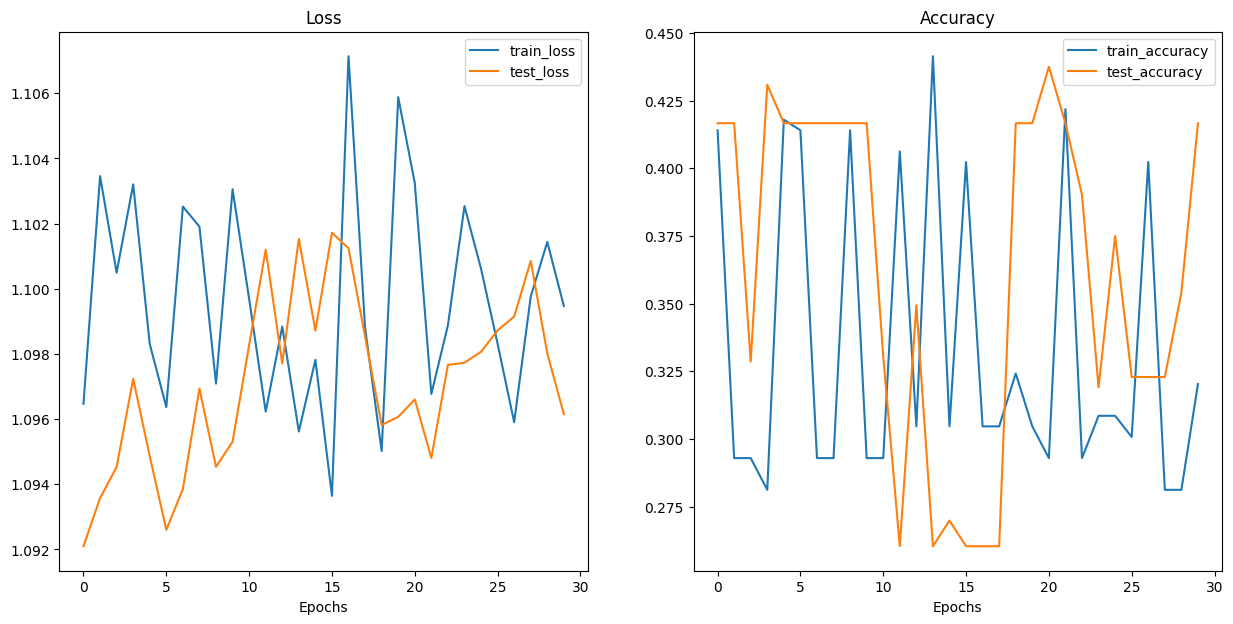

In [ ]:
plot_loss_curves(model_0_results)

## 8. What should an ideal loss curve look like?

A loss curve is one of the most helpful ways to troubleshoot a model

## 9. Model 1: TinyVGG with Data Augmentation
Now let's try another modelling experiment this time using the same model as before with some data augmentation

In [ ]:
# Creating training transform with TrivialAugument
from torchvision import transforms
train_transform_trivial = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=5),
    transforms.ToTensor(),
])

test_transform_simple = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

# 9.2  Create train and test `Dataset`'s and `DataLoader`'s with data augmentation

In [ ]:
# Turn image folders into Datasets
train_dataset_trivial = ImageFolderCustom(
    targ_dir=train_dir,
    transform = train_transform_trivial,
)

test_dataset_simple = ImageFolderCustom(
    targ_dir=test_dir,
    transform=test_transform_simple
)


In [ ]:
import os
from torch.utils.data import DataLoader

# Turn our Datasets into DataLoader

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)

train_dataloader_augmented = DataLoader(
    dataset=train_dataset_trivial,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=os.cpu_count(),
)

test_dataloader_simple = DataLoader(
    dataset=test_dataset_simple,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=os.cpu_count(),
)

In [ ]:
# Define model
model_1 = TinyVGG(
    input_shape=3,
    hidden_units=8,
    output_shape=3
).to(device)

# Define loss funtion and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model_1.parameters(),
    lr=0.1
)

Wonderful! Now we've a model and dataloaders, let's create a loss function and an optimizer and call upon our train() function to train and
evaluate our model.

In [ ]:
model_1_results = train(
    model=model_1,
    train_dataloader=train_dataloader_augmented,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device,
    test_dataloader=test_dataloader_simple,
    epochs=30
)

  0%|          | 0/30 [00:00<?, ?it/s]

Train Loss: 58.0138 | Train Accuracy: 0.28 | Test Loss: 1.1253 | Test Accuracy 0.26
Train Loss: 1.0974 | Train Accuracy: 0.32 | Test Loss: 1.1057 | Test Accuracy 0.42
Train Loss: 1.1279 | Train Accuracy: 0.31 | Test Loss: 1.1115 | Test Accuracy 0.26
Train Loss: 1.1003 | Train Accuracy: 0.29 | Test Loss: 1.1095 | Test Accuracy 0.32
Train Loss: 1.0863 | Train Accuracy: 0.40 | Test Loss: 1.1366 | Test Accuracy 0.26
Train Loss: 1.1245 | Train Accuracy: 0.30 | Test Loss: 1.1476 | Test Accuracy 0.26
Train Loss: 1.0946 | Train Accuracy: 0.43 | Test Loss: 1.1215 | Test Accuracy 0.26
Train Loss: 1.0921 | Train Accuracy: 0.43 | Test Loss: 1.1201 | Test Accuracy 0.26
Train Loss: 1.1224 | Train Accuracy: 0.30 | Test Loss: 1.1312 | Test Accuracy 0.26
Train Loss: 1.1028 | Train Accuracy: 0.28 | Test Loss: 1.1032 | Test Accuracy 0.42
Train Loss: 1.1004 | Train Accuracy: 0.29 | Test Loss: 1.1082 | Test Accuracy 0.26
Train Loss: 1.1026 | Train Accuracy: 0.30 | Test Loss: 1.0970 | Test Accuracy 0.42
Tra

In [ ]:
rand1 = torch.tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
rand2 = torch.tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

(rand1==rand2).sum()

tensor(32)

###  9.4 Plot the loss curves of model 1

A loss curve helps you evaluate your model's performance overtime

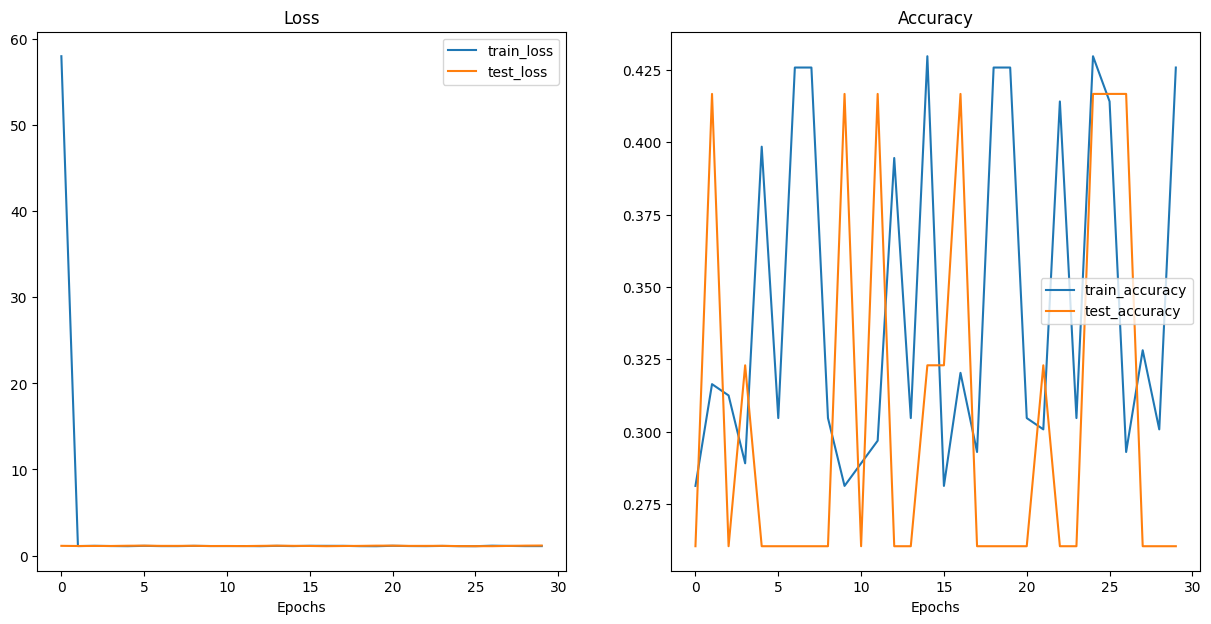

In [ ]:
plot_loss_curves(model_1_results)

## 10. Compare model results

After evaluating our modelling experiments on their own, it's important to compare
them to each other.

There's a few different ways to do this:
1. Hard coding (what we're doing)
2. PyTorch + Tensorboard - https://docs.pytorch.org/docs/stable//tensorboard.html
3. Weights & Biases - https://wandb.ai/site/experiment-tracking
4. MLFlow - https://mlflow.org/

In [ ]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.0964696,0.414062,1.0920982,0.416667
1,1.1034598,0.292969,1.0935756,0.416667
2,1.100494,0.292969,1.0945283,0.328598
3,1.1032063,0.281250,1.0972387,0.430871
4,1.0983061,0.417969,1.0948604,0.416667
5,1.0963693,0.414062,1.0926021,0.416667
6,1.102523,0.292969,1.0938528,0.416667
7,1.1019096,0.292969,1.0969378,0.416667
8,1.0970892,0.414062,1.0945349,0.416667
9,1.1030574,0.292969,1.0953052,0.416667


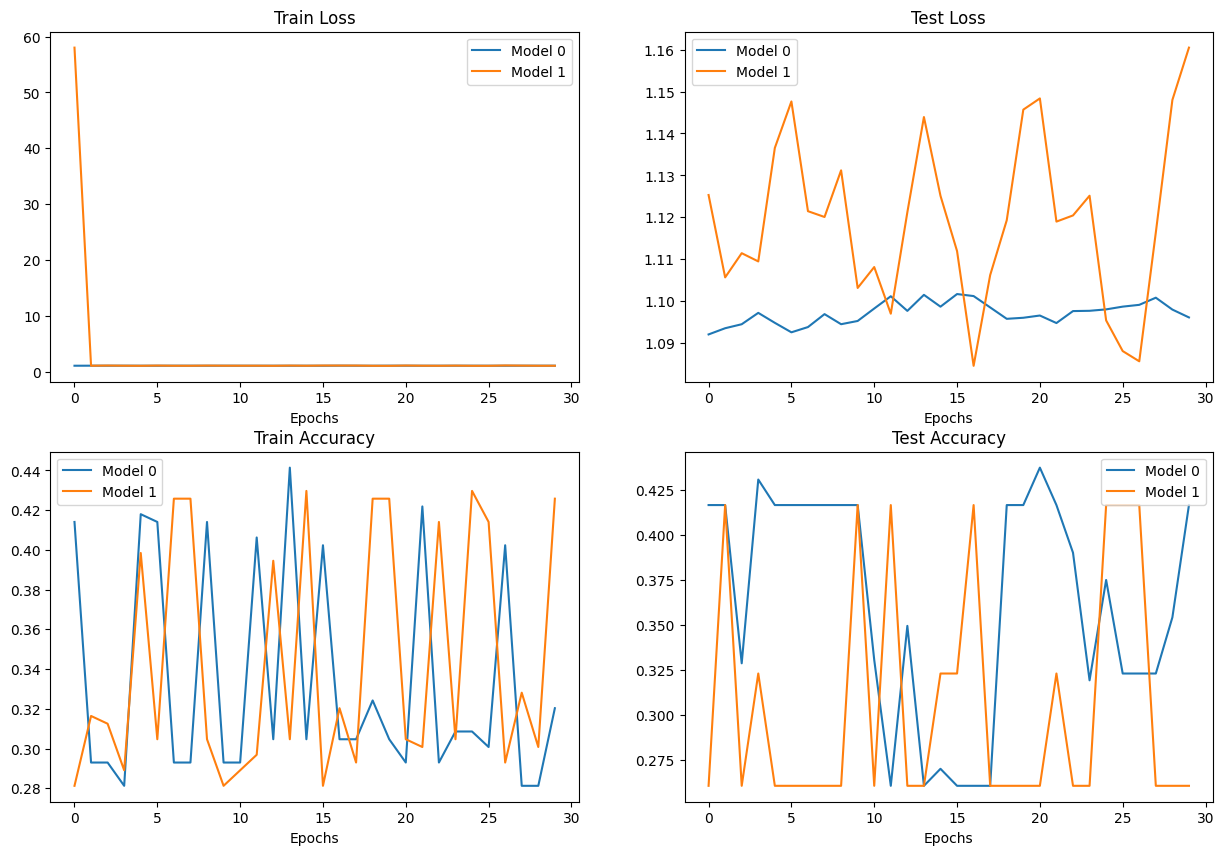

In [ ]:
x# Setup a plot
plt.figure(figsize=(15, 10))

# Get number of epochs
epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs , model_1_df["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot Test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs , model_1_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot train Accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs , model_1_df["train_acc"], label="Model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()


# Plot Test Accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend()


## 11. Making a prediction on a custom image

Although we've trained a model on custom data... how do you make a prediction on a sample/image that's not in dataset.

In [ ]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = data_path / "04-pizza-dad.jpeg"

# Download the image if it already does not exist
if not custom_image_path.is_file():
  with open(custom_image_path, "wb") as f:
    # When downloading from GitHub, need to use the "raw" file link
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/images/04-pizza-dad.jpeg")
    print(f"Downloading {custom_image_path}")

### 11.1 Loading in a custom image with PyTorch
We have to make sure our custom image is in the same format as the data our model was trained on.

* In tensor form with datatype (torch.float32)
* Of shape 64x64x3
* On the right device

We can read an image into PyTorch using -
https://docs.pytorch.org/vision/stable/generated/torchvision.io.decode_image.html#torchvision.io.decode_image


In [ ]:
import torchvision

# Read in custom image
custom_image_uint8 = torchvision.io.decode_image(custom_image_path)

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

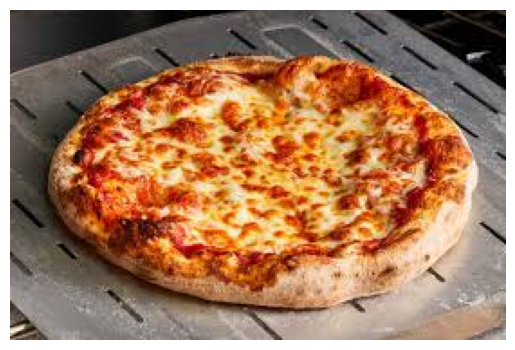

In [ ]:
plt.imshow(custom_image_uint8.permute(1, 2, 0))
plt.axis(False)

In [ ]:
import torchvision

print(f"Custom Image :\n {custom_image_uint8}")
print(f"Custom Image Shape : {custom_image_uint8.shape}")
print(f"Custom Image Datatype  : {custom_image_uint8.dtype}")

Custom Image :
 tensor([[[ 49,  50,  52,  ...,  48,  32,  14],
         [ 58,  59,  60,  ...,  70,  69,  68],
         [ 70,  70,  70,  ...,  51,  67,  82],
         ...,
         [189, 101,  39,  ..., 175, 180, 185],
         [ 41,  72, 113,  ..., 176, 174, 173],
         [145, 148, 148,  ..., 177, 176, 177]],

        [[ 44,  45,  47,  ...,  34,  16,   0],
         [ 53,  54,  55,  ...,  58,  55,  54],
         [ 65,  65,  65,  ...,  41,  55,  70],
         ...,
         [172,  84,  22,  ..., 170, 175, 180],
         [ 24,  55,  96,  ..., 168, 169, 168],
         [128, 131, 131,  ..., 169, 171, 172]],

        [[ 40,  41,  43,  ...,  21,   1,   0],
         [ 49,  50,  51,  ...,  44,  42,  41],
         [ 61,  61,  61,  ...,  31,  43,  58],
         ...,
         [154,  66,   6,  ..., 167, 172, 177],
         [  6,  37,  80,  ..., 165, 166, 165],
         [108, 111, 113,  ..., 166, 168, 169]]], dtype=torch.uint8)
Custom Image Shape : torch.Size([3, 183, 275])
Custom Image Datatype  :

In [ ]:
# Try to make a prediction on an image in uint8 format
model_1.eval()
with torch.inference_mode():
  model_1(custom_image_uint8.to(device))

RuntimeError: Input type (unsigned char) and bias type (float) should be the same

In [ ]:
# Load in the custom image and convert to torch.float32

custom_image = torchvision.io.decode_image(custom_image_path).type(torch.float32)
custom_image

tensor([[[ 49.,  50.,  52.,  ...,  48.,  32.,  14.],
         [ 58.,  59.,  60.,  ...,  70.,  69.,  68.],
         [ 70.,  70.,  70.,  ...,  51.,  67.,  82.],
         ...,
         [189., 101.,  39.,  ..., 175., 180., 185.],
         [ 41.,  72., 113.,  ..., 176., 174., 173.],
         [145., 148., 148.,  ..., 177., 176., 177.]],

        [[ 44.,  45.,  47.,  ...,  34.,  16.,   0.],
         [ 53.,  54.,  55.,  ...,  58.,  55.,  54.],
         [ 65.,  65.,  65.,  ...,  41.,  55.,  70.],
         ...,
         [172.,  84.,  22.,  ..., 170., 175., 180.],
         [ 24.,  55.,  96.,  ..., 168., 169., 168.],
         [128., 131., 131.,  ..., 169., 171., 172.]],

        [[ 40.,  41.,  43.,  ...,  21.,   1.,   0.],
         [ 49.,  50.,  51.,  ...,  44.,  42.,  41.],
         [ 61.,  61.,  61.,  ...,  31.,  43.,  58.],
         ...,
         [154.,  66.,   6.,  ..., 167., 172., 177.],
         [  6.,  37.,  80.,  ..., 165., 166., 165.],
         [108., 111., 113.,  ..., 166., 168., 169.]]]

In [ ]:
model_1.eval()
with torch.inference_mode():
  model_1(custom_image.to(device))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (8x2730 and 1352x3)

In [ ]:
from PIL import Image

image = Image.open(custom_image_path)
image_transformed = test_transform_simple(image) # resize and convert to proper tensor

model_1.eval()
with torch.inference_mode():
  y_logit = model_1(image_transformed.unsqueeze(0).to(device))
  y_pred = y_logit.argmax(dim=1)
class_names[y_pred.item()]

'pizza'

Note, to make a prediction on a custom image we had to:
* Load the image and turn it into a tensor
* Make sure the image was the same datatype as the model (torch.float32)

* Make sure the image was the same shape as the data the model was trained on
(3X64x64) with a batch size... (1, 3, 64, 64),

* Make sure the image was on the same device as our model

In [ ]:
# Convert logits -> prediction probabilities
custom_image_pred_probs = torch.softmax(y_logit, dim=1)
custom_image_pred_probs

tensor([[0.4171, 0.2501, 0.3328]])

In [ ]:
# Convert prediction probabilities -> prediction labels
custom_image_pred_labels = torch.argmax(y_logit, dim=1)
custom_image_pred_labels

tensor([0])

In [ ]:
class_names[custom_image_pred_labels]

'pizza'

### 11.3 Putting custom image prediction together: building a function
Ideal outcome:

A function where we pass an image path and our model and plot the image + prediction as the title.

In [ ]:
from PIL import Image
from torchvision import transforms
def plot_pred_label(model:nn.Module,
                    image_path:str,
                    class_names:List[str],
                    device:str,
                    transform:torchvision.transforms.transforms.Compose
):

  image = Image.open(image_path)
  transformed_image = transform(image)
  transformed_image = transformed_image.unsqueeze(dim=0).to(device)

  model.eval()
  with torch.inference_mode():
    logits = model(transformed_image)
    pred_idx = logits.argmax(dim=1)
    pred_probs = logits.softmax(dim=1)
    pred_probs = pred_probs.max().item()

  plt.imshow(image)
  if class_names is not None:
    plt.title(f"Predicted Label:{class_names[pred_idx]} | Pred Probability: {pred_probs*100:.2f}%")
  else:
    plt.title(f"Predicted Label:{pred_idx} | Pred Probability: {pred_probs*100:.2f}%")

  plt.axis(False)

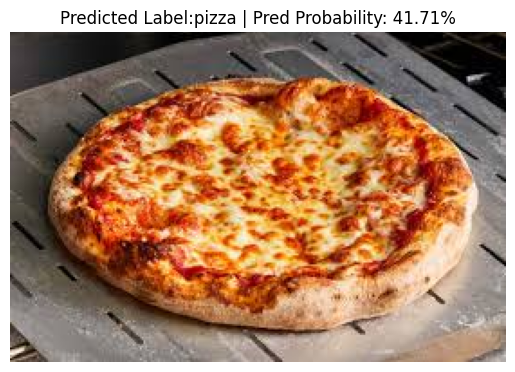

In [ ]:
plot_pred_label(
    model_1,
    custom_image_path,
    class_names,
    device,
    test_transform_simple
)